ГРУППОВОЙ ПРОЕКТ №5. DEEP LEARNING

ноутбук 2: рекомендация цены товара - полносвязная нейронная сеть

ПОСТАНОВКА ЗАДАЧИ

бизнес-задача из ноутбука 1: продавец заводит карточку товара, модель по атрибутам рекомендует адекватную цену

на языке DL это регрессия: по табличным признакам карточки предсказываем log(1 + цена) - по EDA распределение цены сильно скошено, в логарифме почти симметричное. лосс - MSE на логе, а для бизнеса смотрим MAE в рупиях (средняя ошибка рекомендации) и медианную относительную ошибку

сравниваем 5 конфигураций полносвязной сети - от мелкого baseline до сети с текстовыми признаками из названия, плюс отдельно подбираем learning rate для лучшей. все эксперименты логируем в wandb: параметры, метрики по эпохам, артефакты моделей и сами данные

In [1]:
import os
import ast
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
# TensorDataset на семинарах не разбирали, доки: https://docs.pytorch.org/docs/stable/data.html
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# выключаем спам wandb в ячейках (https://docs.wandb.ai/guides/track/environment-variables/)
os.environ['WANDB_SILENT'] = 'true'
import wandb

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.path.abspath('../data/kagglehub')

import kagglehub

catalog_path = kagglehub.dataset_download('djagatiya/myntra-fashion-product-dataset')
catalog = pd.read_csv(os.path.join(catalog_path, 'Fashion Dataset v2.csv'))
catalog.shape

(14214, 11)

ПРИЗНАКИ ИЗ p_attributes

словарь атрибутов лежит в каждой строке как текст. парсим его через ast.literal_eval (безопасный разбор питоновских литералов, на семинарах не было: https://docs.python.org/3/library/ast.html#ast.literal_eval) и вытаскиваем 5 атрибутов с лучшим покрытием и вменяемым числом значений: повод, уход, паттерн, ткань, длина рукава

In [3]:
attrs = catalog['p_attributes'].apply(ast.literal_eval)

for col, key in [('occasion', 'Occasion'), ('wash_care', 'Wash Care'), ('pattern', 'Pattern'),
                 ('fabric', 'Fabric'), ('sleeve', 'Sleeve Length')]:
    catalog[col] = attrs.apply(lambda d: d.get(key, 'unknown')).replace('NA', 'unknown')

catalog[['occasion', 'wash_care', 'pattern', 'fabric', 'sleeve']].head()

,occasion,wash_care,pattern,fabric,sleeve
0,Festive,Machine Wash,unknown,unknown,Three-Quarter Sleeves
1,Fusion,Hand Wash,unknown,unknown,Sleeveless
2,Daily,Hand Wash,unknown,unknown,Three-Quarter Sleeves
3,Daily,Hand Wash,unknown,unknown,Three-Quarter Sleeves
4,Daily,Machine Wash,Printed,Cotton,Three-Quarter Sleeves


In [4]:
(catalog[['occasion', 'wash_care', 'pattern', 'fabric', 'sleeve']] != 'unknown').mean().round(2)

occasion     0.92
wash_care    0.92
pattern      0.73
fabric       0.73
sleeve       0.55
dtype: float64

у occasion и wash_care покрытие за 90%, у pattern и fabric ~73%, у sleeve 55%. где атрибута нет - ставим unknown, для one-hot это просто еще одна категория

ОСТАЛЬНЫЕ ПРИЗНАКИ

из products берем основной тип товара (первый в списке комплекта) и размер комплекта. рейтинги: пропуски заполняем нулями и добавляем флаг has_rating - сам факт отсутствия оценок это сигнал. ratingCount скошен так же как цена, логарифмируем

In [5]:
catalog['main_product'] = catalog['products'].str.split(',').str[0]
catalog['n_items'] = catalog['products'].str.split(',').apply(len)
catalog['n_attrs'] = attrs.apply(len)

catalog['has_rating'] = (~catalog['ratingCount'].isna()).astype(int)
catalog['ratingCount'] = np.log1p(catalog['ratingCount'].fillna(0))
catalog['avg_rating'] = catalog['avg_rating'].fillna(0)

catalog['main_product'].value_counts().head(10)

main_product
Top               1122
Jeans              981
Saree              899
Dupatta            874
Kurta              849
Lehenga            849
Trousers           762
Jacket             735
Jumpsuit           699
Dress Material     628
Name: count, dtype: int64

типов товара 373, брендов 1022, тканей 59 - редкие категории сворачиваем в other, иначе one-hot раздует матрицу и редкие колонки все равно ничему не научат

In [6]:
top_fabric = catalog['fabric'].value_counts().head(10).index
catalog['fabric'] = catalog['fabric'].where(catalog['fabric'].isin(top_fabric), 'other')

top_mp = catalog['main_product'].value_counts().head(15).index
catalog['main_product'] = catalog['main_product'].where(catalog['main_product'].isin(top_mp), 'other')

top_brand = catalog['brand'].value_counts().head(30).index
catalog['brand_top'] = catalog['brand'].where(catalog['brand'].isin(top_brand), 'other')

In [7]:
num_cols = ['ratingCount', 'avg_rating', 'has_rating', 'n_items', 'n_attrs']
cat_cols = ['occasion', 'wash_care', 'pattern', 'fabric', 'sleeve', 'main_product', 'colour', 'brand_top']

# one-hot через get_dummies, в семинарах не встречалось - https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
X = pd.get_dummies(catalog[num_cols + cat_cols], columns=cat_cols).astype(float)
y = np.log1p(catalog['price'])
X.shape

(14214, 152)

итого 152 признака: 5 числовых, остальное one-hot. бренд пока топ-30 + other, к полному списку брендов вернемся в конфигурации 4

In [8]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, random_state=2026)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=2026)

len(X_train), len(X_val), len(X_test)

(9949, 2132, 2133)

In [9]:
mean, std = X_train[num_cols].mean(), X_train[num_cols].std()
for part in (X_train, X_val, X_test):
    part[num_cols] = (part[num_cols] - mean) / std

числовые признаки стандартизуем по статистикам трейна, чтобы не подсматривать в валидацию и тест. деление: 70% обучение, по 15% валидация (по ней сравниваем конфигурации) и тест (трогаем один раз в конце)

перед сетями - точка отсчета: наивный прогноз, рекомендуем всем товарам просто медианную цену трейна. любая модель обязана бить этот уровень

In [10]:
naive = np.expm1(y_train.median())
naive_val = np.abs(np.expm1(y_val) - naive).mean()
naive_test = np.abs(np.expm1(y_test) - naive).mean()
round(naive), round(naive_val), round(naive_test)

(2249, 1426, 1459)

медианная цена трейна 2249 рупий. если рекомендовать ее всем товарам подряд, ошибка 1426 рупий на валидации и 1459 на тесте. это планка - сеть которая не бьет эти цифры не нужна

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
device

device(type='mps')

ЛОГИРОВАНИЕ В WANDB

проект gp5-fashion-dl. каждая конфигурация - отдельный run: параметры архитектуры и обучения, метрики по эпохам, артефакт обученной модели. готовые train/val/test грузим артефактом данных - так любой эксперимент воспроизводится имея только доступ к wandb, данные искать отдельно не надо

In [12]:
os.makedirs('../data/processed', exist_ok=True)

for part, part_y, name in [(X_train, y_train, 'train'), (X_val, y_val, 'val'), (X_test, y_test, 'test')]:
    tmp = part.copy()
    tmp['target'] = part_y
    tmp.to_csv('../data/processed/' + name + '.csv', index=False)

run = wandb.init(project='gp5-fashion-dl', name='tabular-data-upload', job_type='dataset')
art = wandb.Artifact('tabular-data', type='dataset', description='train/val/test для рекомендации цены (Myntra)')
art.add_dir('../data/processed')
run.log_artifact(art)
run.finish()

ФУНКЦИИ ОБУЧЕНИЯ

по мотивам семинара 17, только под регрессию: train_epoch делает шаги по батчам, evaluate считает лосс на логе и MAE в рупиях (предсказание возвращаем из лога через expm1). run_experiment - один эксперимент целиком: запуск в wandb, обучение, логирование по эпохам, сохранение модели артефактом

In [13]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [14]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb).squeeze(1), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(yb)
    return total / len(loader.dataset)


def evaluate(model, X_t, y_t, criterion):
    model.eval()
    with torch.no_grad():
        pred = model(X_t).squeeze(1)
        loss = criterion(pred, y_t).item()
        mae = (torch.expm1(pred) - torch.expm1(y_t)).abs().mean().item()
    return loss, mae

In [15]:
def run_experiment(name, model, loader, X_v, y_v, config):
    run = wandb.init(project='gp5-fashion-dl', name=name, config=config)
    run.use_artifact('tabular-data:latest')

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

    for epoch in range(config['epochs']):
        tl = train_epoch(model, loader, optimizer, criterion)
        vl, vmae = evaluate(model, X_v, y_v, criterion)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['val_mae'].append(vmae)
        run.log({'epoch': epoch + 1, 'train_loss': tl, 'val_loss': vl, 'val_mae_inr': vmae})

    path = '../models/' + name + '.pt'
    torch.save(model.state_dict(), path)
    art = wandb.Artifact(name, type='model')
    art.add_file(path)
    run.log_artifact(art)
    run.finish()
    return history

КОНФИГУРАЦИЯ 1: BASELINE

самая простая сеть - один скрытый слой на 64 нейрона с ReLU. это точка отсчета среди сетей: если дальше усложнение архитектуры не бьет этот результат, значит усложнение не нужно

In [16]:
seed_everything(2026)

model_1 = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)
model_1

Sequential(
  (0): Linear(in_features=152, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)

In [17]:
config_1 = {'arch': '64', 'batchnorm': False, 'dropout': 0, 'n_features': X.shape[1],
            'optimizer': 'Adam', 'lr': 1e-3, 'batch_size': 256, 'epochs': 40, 'seed': 2026}

hist_1 = run_experiment('fcnn-1-baseline', model_1, train_loader, X_val_t, y_val_t, config_1)
round(min(hist_1['val_mae']))

992

уже самая простая сеть дает MAE 992 на валидации против 1426 у наивного - минус треть ошибки. сходится медленно (лучшая эпоха 36 из 40), переобучения нет

КОНФИГУРАЦИЯ 2: ГЛУБОКАЯ СЕТЬ

три скрытых слоя 512-256-128. емкость сильно больше - проверяем дает ли что-то глубина сама по себе. регуляризации нет, так что ждем переобучения

In [18]:
seed_everything(2026)

model_2 = nn.Sequential(
    nn.Linear(X.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

config_2 = {'arch': '512-256-128', 'batchnorm': False, 'dropout': 0, 'n_features': X.shape[1],
            'optimizer': 'Adam', 'lr': 1e-3, 'batch_size': 256, 'epochs': 40, 'seed': 2026}

hist_2 = run_experiment('fcnn-2-deep', model_2, train_loader, X_val_t, y_val_t, config_2)
round(min(hist_2['val_mae']))

979

глубокая сеть учится быстрее и выходит на лучший val MAE 979 уже к 19 эпохе, но дальше начинает переобучатся: train лосс падает вдвое ниже val (0.09 против 0.20), а val MAE к 40 эпохе ползет обратно вверх до 1007. емкости хватает с запасом, не хватает регуляризации - проверим в конфиге 3

КОНФИГУРАЦИЯ 3: ГЛУБОКАЯ + BATCHNORM + DROPOUT

та же глубина 512-256-128, но после каждого слоя BatchNorm и Dropout 0.3 - техники из семинара 19. BatchNorm стабилизирует обучение, Dropout борется с переобучением. сравнение с конфигом 2 покажет что дает регуляризация при той же емкости

In [19]:
seed_everything(2026)

model_3 = nn.Sequential(
    nn.Linear(X.shape[1], 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 1)
).to(device)

config_3 = {'arch': '512-256-128', 'batchnorm': True, 'dropout': 0.3, 'n_features': X.shape[1],
            'optimizer': 'Adam', 'lr': 1e-3, 'batch_size': 256, 'epochs': 40, 'seed': 2026}

hist_3 = run_experiment('fcnn-3-batchnorm-dropout', model_3, train_loader, X_val_t, y_val_t, config_3)
round(min(hist_3['val_mae']))

987

регуляризация переобучение сняла (val лосс больше не растет), но лучше не стало - val MAE 987, как у первых двух. dropout еще и замедлил сходимость. видимо переобучение тут не главная проблема

КОНФИГУРАЦИЯ 4: ЭМБЕДДИНГИ ДЛЯ БРЕНДА И ЦВЕТА

подход которого не было на семинарах - entity embeddings для категориальных признаков (идея из статьи https://arxiv.org/abs/1604.06737, слой - обычный nn.Embedding: https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

мотивация: в конфигах 1-3 от 1022 брендов осталось топ-30 + other, остальные 992 бренда слиплись в одну категорию - а бренд по EDA один из главных признаков цены. эмбеддинг решает это: каждый бренд получает свой обучаемый вектор (16 чисел), сеть сама расставляет похожие по ценовой политике бренды рядом. это те же эмбеддинги что были для слов в семинаре 20-21, только для табличной категории. цвету тоже даем вектор на 8 чисел вместо one-hot

In [20]:
# категории в целые номера через cat.codes (https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html)
catalog['brand_code'] = catalog['brand'].astype('category').cat.codes
catalog['colour_code'] = catalog['colour'].astype('category').cat.codes

cat_cols_emb = ['occasion', 'wash_care', 'pattern', 'fabric', 'sleeve', 'main_product']
X_emb = pd.get_dummies(catalog[['brand_code', 'colour_code'] + num_cols + cat_cols_emb],
                       columns=cat_cols_emb).astype(float)
X_emb.shape

(14214, 73)

In [21]:
X_emb_train = X_emb.loc[X_train.index].copy()
X_emb_val = X_emb.loc[X_val.index].copy()
X_emb_test = X_emb.loc[X_test.index].copy()

mean_e, std_e = X_emb_train[num_cols].mean(), X_emb_train[num_cols].std()
for part in (X_emb_train, X_emb_val, X_emb_test):
    part[num_cols] = (part[num_cols] - mean_e) / std_e

X_emb_train_t = torch.tensor(X_emb_train.values, dtype=torch.float32)
X_emb_val_t = torch.tensor(X_emb_val.values, dtype=torch.float32).to(device)

train_loader_emb = DataLoader(TensorDataset(X_emb_train_t, y_train_t), batch_size=256, shuffle=True)

In [22]:
for part, name in [(X_emb_train, 'train_emb'), (X_emb_val, 'val_emb'), (X_emb_test, 'test_emb')]:
    part.to_csv('../data/processed/' + name + '.csv', index=False)

run = wandb.init(project='gp5-fashion-dl', name='tabular-data-upload-v2', job_type='dataset')
art = wandb.Artifact('tabular-data', type='dataset', description='добавлены варианты с кодами бренда/цвета для эмбеддингов')
art.add_dir('../data/processed')
run.log_artifact(art)
run.finish()

In [23]:
class PriceNetEmb(nn.Module):
    def __init__(self, n_brands, n_colours, n_rest):
        super().__init__()
        self.brand_emb = nn.Embedding(n_brands, 16)
        self.colour_emb = nn.Embedding(n_colours, 8)
        self.net = nn.Sequential(
            nn.Linear(16 + 8 + n_rest, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # первые два столбца - номера бренда и цвета, остальное обычные признаки
        b = self.brand_emb(x[:, 0].long())
        c = self.colour_emb(x[:, 1].long())
        return self.net(torch.cat([b, c, x[:, 2:]], dim=1))

In [24]:
seed_everything(2026)

model_4 = PriceNetEmb(catalog['brand_code'].nunique(), catalog['colour_code'].nunique(),
                      X_emb.shape[1] - 2).to(device)

config_4 = {'arch': 'emb(brand16+colour8)-256-128', 'batchnorm': True, 'dropout': 0.3,
            'n_features': X_emb.shape[1], 'optimizer': 'Adam', 'lr': 1e-3,
            'batch_size': 256, 'epochs': 40, 'seed': 2026}

hist_4 = run_experiment('fcnn-4-embeddings', model_4, train_loader_emb, X_emb_val_t, y_val_t, config_4)
round(min(hist_4['val_mae']))

1010

а вот это обидно: эмбеддинги ожиданий не оправдали, val MAE 1010 - хуже всех. причина скорее всего в данных: брендов 1022 на 14 тыс товаров, у большинства по несколько примеров и осмысленный вектор из них не выучишь. топ-30 + other в этом смысле честнее. идея красивая, но на каталоге такого размера не работает

КОНФИГУРАЦИЯ 5: + ТЕКСТ НАЗВАНИЯ (TF-IDF)

пока вырисовывается что дело не в архитектуре а в признаках. проверим это напрямую: добавим к базовым 152 признакам текст названия товара. в названии сидит то чего нет в атрибутах - тип вещи, материал, комплектация ('Silk Saree', 'Trolley Bag', 'Kurta Set')

текст кодируем через TF-IDF как в семинаре 20-21, берем топ-300 слов. векторайзер обучаем только на трейне чтобы не было утечки. архитектуру берем из конфига 2 (лучший val MAE среди сетей) - меняются только признаки, так эффект текста виден в чистую

In [25]:
vec = TfidfVectorizer(max_features=300)
vec.fit(catalog.loc[X_train.index, 'name'])

text_train = vec.transform(catalog.loc[X_train.index, 'name']).toarray()
text_val = vec.transform(catalog.loc[X_val.index, 'name']).toarray()
text_test = vec.transform(catalog.loc[X_test.index, 'name']).toarray()

X5_train = np.hstack([X_train.values, text_train])
X5_val = np.hstack([X_val.values, text_val])
X5_test = np.hstack([X_test.values, text_test])
X5_train.shape

(9949, 452)

In [26]:
for part, part_y, name in [(X5_train, y_train, 'train_text'), (X5_val, y_val, 'val_text'), (X5_test, y_test, 'test_text')]:
    tmp = pd.DataFrame(part)
    tmp['target'] = part_y.values
    tmp.to_csv('../data/processed/' + name + '.csv', index=False)

run = wandb.init(project='gp5-fashion-dl', name='tabular-data-upload-v3', job_type='dataset')
art = wandb.Artifact('tabular-data', type='dataset', description='добавлены варианты с tf-idf признаками названия')
art.add_dir('../data/processed')
run.log_artifact(art)
run.finish()

In [27]:
X5_train_t = torch.tensor(X5_train, dtype=torch.float32)
X5_val_t = torch.tensor(X5_val, dtype=torch.float32).to(device)

train_loader_5 = DataLoader(TensorDataset(X5_train_t, y_train_t), batch_size=256, shuffle=True)

In [28]:
seed_everything(2026)

model_5 = nn.Sequential(
    nn.Linear(X5_train.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

config_5 = {'arch': '512-256-128', 'batchnorm': False, 'dropout': 0, 'n_features': X5_train.shape[1],
            'features': 'base152 + tfidf300(name)', 'optimizer': 'Adam', 'lr': 1e-3,
            'batch_size': 256, 'epochs': 40, 'seed': 2026}

hist_5 = run_experiment('fcnn-5-tfidf', model_5, train_loader_5, X5_val_t, y_val_t, config_5)
round(min(hist_5['val_mae']))

851

вот это уже другой разговор: val MAE 851 против 979 у точно такой же сети без текста - минус 13% ошибки от одних только признаков, больше чем дали все архитектурные вариации вместе взятые. честно говоря такого отрыва не ждали. гипотеза подтвердилась, дело было не в архитектуре

занятно что сеть при этом жестко переобучается (train лосс 0.03 против val 0.16) - но даже так бьет всех с запасом

ПОДБОР LEARNING RATE

до сих пор все обучали на lr = 1e-3 (дефолт Adam). для лучшей конфигурации проверим соседние значения - в 3 раза меньше и в 3 раза больше. если дефолт не оптимален, это дешевый способ добрать качество

In [29]:
lr_hists = {}
for lr in [3e-4, 3e-3]:
    seed_everything(2026)
    m = nn.Sequential(
        nn.Linear(X5_train.shape[1], 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 1)
    ).to(device)
    cfg = dict(config_5)
    cfg['lr'] = lr
    lr_hists[lr] = run_experiment('fcnn-5-tfidf-lr' + str(lr), m, train_loader_5, X5_val_t, y_val_t, cfg)

{lr: round(min(h['val_mae'])) for lr, h in lr_hists.items()}

{0.0003: 847, 0.003: 856}

3e-4 дает 847, дефолт 1e-3 - 851, 3e-3 - 856. разница меньше процента, дефолт норм. из любопытного: на 3e-4 сеть за 40 эпох так и не начала переобучаться (лучшая эпоха - последняя), маленький шаг сам по себе работает как мягкая регуляризация. дальше lr не крутим

СРАВНЕНИЕ КОНФИГУРАЦИЙ

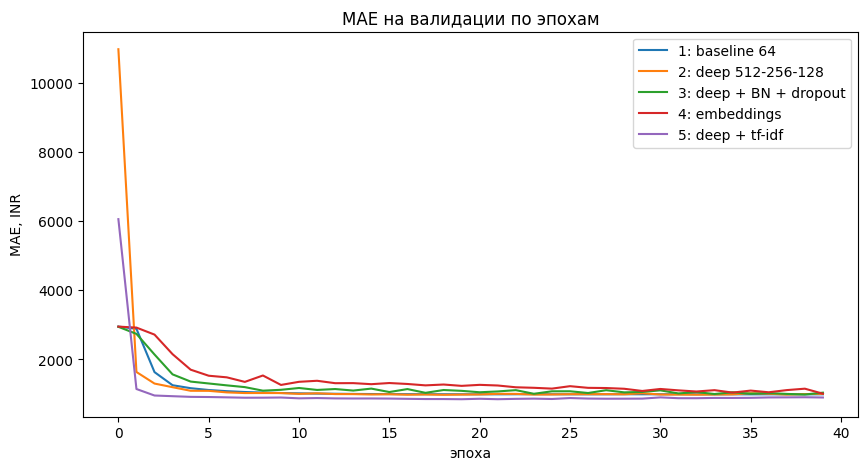

In [30]:
plt.figure(figsize=(10, 5))
for hist, label in [(hist_1, '1: baseline 64'), (hist_2, '2: deep 512-256-128'),
                    (hist_3, '3: deep + BN + dropout'), (hist_4, '4: embeddings'),
                    (hist_5, '5: deep + tf-idf')]:
    plt.plot(hist['val_mae'], label=label)
plt.title('MAE на валидации по эпохам')
plt.xlabel('эпоха')
plt.ylabel('MAE, INR')
plt.legend()
plt.show()

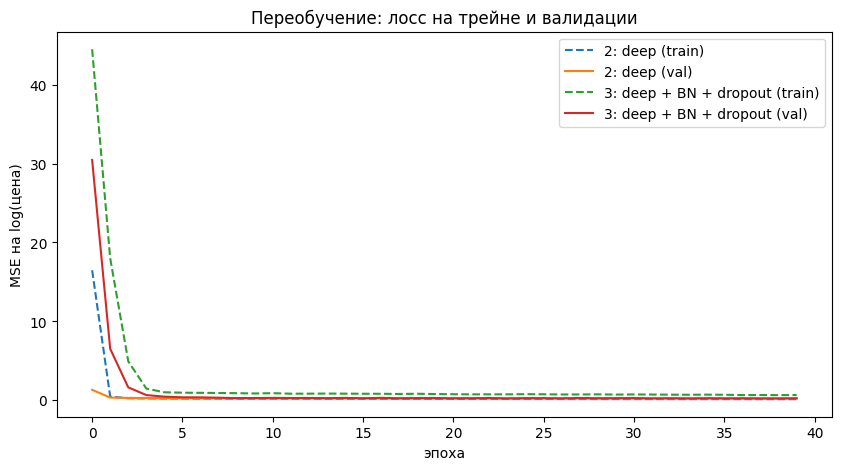

In [31]:
plt.figure(figsize=(10, 5))
for hist, label in [(hist_2, '2: deep'), (hist_3, '3: deep + BN + dropout')]:
    plt.plot(hist['train_loss'], '--', label=label + ' (train)')
    plt.plot(hist['val_loss'], label=label + ' (val)')
plt.title('Переобучение: лосс на трейне и валидации')
plt.xlabel('эпоха')
plt.ylabel('MSE на log(цена)')
plt.legend()
plt.show()

финальная проверка на тесте - его трогаем один раз. считаем MAE в рупиях и медианную относительную ошибку, наивный прогноз медианой кладем в таблицу как точку отсчета

In [32]:
X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).to(device)
X_emb_test_t = torch.tensor(X_emb_test.values, dtype=torch.float32).to(device)
X5_test_t = torch.tensor(X5_test, dtype=torch.float32).to(device)


def test_metrics(model, X_t):
    model.eval()
    with torch.no_grad():
        pred = torch.expm1(model(X_t).squeeze(1))
    true = torch.expm1(y_test_t)
    mae = (pred - true).abs().mean().item()
    medape = ((pred - true).abs() / true).median().item()
    return round(mae), round(100 * medape, 1)

In [33]:
true_test = np.expm1(y_test.values)
naive_medape = round(100 * np.median(np.abs(naive - true_test) / true_test), 1)

rows = [['0: наивный (медиана трейна)', 0, round(naive_val), round(naive_test), naive_medape]]
for name, model, hist, X_t in [('1: baseline 64', model_1, hist_1, X_test_t),
                               ('2: deep 512-256-128', model_2, hist_2, X_test_t),
                               ('3: deep + BN + dropout', model_3, hist_3, X_test_t),
                               ('4: embeddings', model_4, hist_4, X_emb_test_t),
                               ('5: deep + tf-idf', model_5, hist_5, X5_test_t)]:
    mae, medape = test_metrics(model, X_t)
    n_params = sum(p.numel() for p in model.parameters())
    rows.append([name, n_params, round(min(hist['val_mae'])), mae, medape])

results = pd.DataFrame(rows, columns=['конфигурация', 'параметров', 'best val MAE', 'test MAE, INR', 'test medAPE, %'])
results

,конфигурация,параметров,best val MAE,"test MAE, INR","test medAPE, %"
0,0: наивный (медиана трейна),0,1426,1459,40.7
1,1: baseline 64,9857,992,964,24.0
2,2: deep 512-256-128,242689,979,982,23.6
3,3: deep + BN + dropout,244481,987,1026,25.6
4,4: embeddings,75121,1010,1008,27.5
5,5: deep + tf-idf,396289,851,906,21.6


итог сравнения: все архитектурные вариации (конфиги 1-4) топчутся в коридоре 964-1026 рупий на тесте, разница около 6%. а добавка текста названия сбрасывает MAE до 906 и medAPE до 21.6% - при том что наивный прогноз дает 1459 и 40.7%. финальная модель режет ошибку наивного почти вдвое

главный вывод: качество решает не глубина сети, а информативность признаков. для бизнеса это значит что вкладываться надо в обогащение карточки товара (описания, категории, атрибуты), а не в наращивание слоев

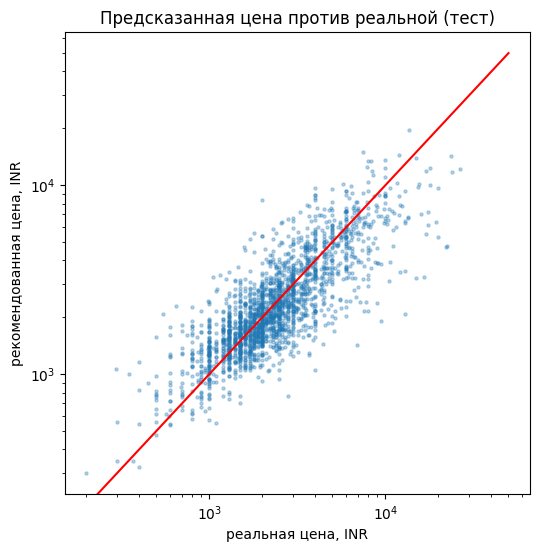

In [34]:
model_best = model_5
model_best.eval()
with torch.no_grad():
    pred_test = torch.expm1(model_best(X5_test_t).squeeze(1)).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(true_test, pred_test, s=5, alpha=0.3)
plt.plot([0, 50000], [0, 50000], color='red')
plt.xscale('log')
plt.yscale('log')
plt.title('Предсказанная цена против реальной (тест)')
plt.xlabel('реальная цена, INR')
plt.ylabel('рекомендованная цена, INR')
plt.show()

In [35]:
# режем тест на 4 ценовых сегмента по квартилям, qcut не из семинаров: https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
seg = pd.DataFrame({'price': true_test, 'err': np.abs(pred_test - true_test)})
seg['rel_err'] = seg['err'] / seg['price']
seg['сегмент'] = pd.qcut(seg['price'], 4, labels=['дешевые', 'ниже среднего', 'выше среднего', 'дорогие'])
seg.groupby('сегмент', observed=True)[['err', 'rel_err']].median().round(2)

,err,rel_err
сегмент,,
дешевые,269.26,0.24
ниже среднего,311.10,0.17
выше среднего,536.37,0.20
дорогие,1366.23,0.28


по ценовым сегментам интересно: лучше всего модель работает в середине каталога - 17-20% медианной ошибки. на краях хуже: у дешевых товаров даже небольшая ошибка в рупиях велика в процентах (24%), у дорогих ошибка 1366 рупий (28%) - премиальное ценообразование завязано на бренд и неочевидные факторы, по атрибутам его не угадаешь

практически: рекомендацию можно включать как есть для основной массы каталога, для дорогих товаров показывать вилку а не точку

ИТОГИ ПО ТАБЛИЧНОЙ ЗАДАЧЕ

что сделали: распарсили p_attributes, собрали 152 базовых признака и 300 tf-idf признаков из названия, обучили и сравнили 5 конфигураций полносвязной сети плюс подбор learning rate для лучшей. каждый эксперимент - отдельный запуск в wandb с параметрами, метриками по эпохам и артефактом модели, обработанные данные тоже лежат в wandb артефактом

главные выводы:

- задача решается: финальная модель рекомендует цену с медианной ошибкой 21.6% против 40.7% у наивного прогноза медианой - ошибка режется почти вдвое
- архитектура влияет слабо: четыре конфигурации от 10 тыс до 245 тыс параметров уложились в 6% разницы. глубина без регуляризации переобучается (видно по лоссам), BatchNorm+Dropout переобучение лечат но итог не улучшают
- эмбеддинги на 1022 бренда проиграли простому топ-30+other: слишком мало примеров на бренд
- решают признаки, не слои: 300 tf-idf слов из названия дали минус 13% ошибки - больше чем все архитектурные вариации вместе
- learning rate: дефолт 1e-3 почти оптимален, 3e-4 дает 847 против 851 - в пределах шума
- слабые места: дорогой сегмент (28% ошибки) и совсем дешевый (24%), середина каталога - 17-20%

бизнес-рекомендация: включать модель как подсказку цены при заведении карточки, для дорогих товаров показывать диапазон вместо точки. потенциал дальнейшего роста - снова в признаках: полное описание товара, категория с фото (ее как раз дает модель из ноутбука 3), цены похожих товаров